# ¿Sirve de algo el predictor sobre embeddings?

Experimento **temporal y aislado**. El baseline trae dos piezas apagadas: `features.py`
(`FeatureStore`, que sabe leer los embeddings congelados de MRI / biopsia / prostatectomía)
y `tools/predictor.py` (`run_predictor`, un stub que devuelve `null`). El repo las documenta
como punto de extensión y nunca las usa. La pregunta de este cuaderno es concreta:

> **si las encendemos, ¿cambia el comportamiento del agente y mejora la línea base?**

Todo lo que produce este experimento vive en `delete_test/`. El árbol del repo se deja
exactamente como estaba (sección 10).

---

### Cómo leer este cuaderno

| Sección | Qué responde |
|---|---|
| **1** | qué señal hay de verdad en los embeddings, medida honestamente |
| **2** | qué devuelve la herramienta cuando se enciende, literal |
| **3** | la sonda que obligó a rediseñar el experimento |
| **4** | cómo cambia el comportamiento del agente |
| **5** | la puntuación oficial de los dos brazos |
| **6** | dónde cambió: puerta de decisión y casos que voltearon |
| **7** | tarea 3 en detalle (su ranking es solo el c-index) |
| **8** | descomposición del `case_score` por componente |
| **9** | veredicto |
| **10** | reversión: qué se tocó y cómo queda el repo |

## 0. Diseño experimental

**Tres brazos**, el mismo modelo cargado una sola vez, los mismos casos, el mismo orden:

| Brazo | `agent.predictor.enabled` | Prompt de sistema | Para qué |
|---|---|---|---|
| `off` | `false` | intacto | **control** |
| `on` | `true` | intacto | **sonda** — encender el interruptor a secas (10 casos/tarea) |
| `on_prompt` | `true` | + anuncio de la herramienta | **tratamiento** |

Tres decisiones que hacen que el número signifique algo:

**a) Predicciones out-of-fold.** La cabeza se entrena con `StratifiedKFold(5)`: la predicción
que la herramienta le entrega a un caso viene de un modelo que **nunca vio la etiqueta de ese
caso**. Sin esto, encender el predictor sería pasarle la respuesta al agente y el "mejora la
línea base" no querría decir nada.

**b) `temperature = 0`.** Con la temperatura 1.0 del baseline, dos corridas idénticas ya
difieren entre sí; el efecto de una herramienta quedaría enterrado en ruido de muestreo. A 0
la única diferencia entre brazos es la herramienta. El precio: el número absoluto del control
**no** es el 0,5651 de `dev/baseline_reference.json` — se compara contra el control de aquí,
no contra aquella cifra.

**c) Los 238 casos etiquetados** (T1 91 · T2 72 · T3 75), no una muestra. Un caso etiquetado
sin salida se puntúa como fallo (`pred=None`), que es lo que hace Grand Challenge cuando un
contenedor no entrega.

**Por qué hubo que añadir el brazo `on_prompt`:** el sondeo de la sección 3. En corto: con el
interruptor encendido y el prompt intacto, el agente no llama a la herramienta ni una vez.

In [1]:
# --- Entorno ---------------------------------------------------------------
import json, os, sys, warnings, collections, importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
%matplotlib inline

def _raiz(p: Path) -> Path:
    for c in [p, *p.parents]:
        if (c / 'pyproject.toml').exists() and (c / 'src' / 'chimera_agent_baseline').exists():
            return c
    raise RuntimeError('No encuentro la raiz del repo')

REPO = _raiz(Path.cwd().resolve()); os.chdir(REPO)
AQUI = REPO / 'delete_test'
sys.path.insert(0, str(REPO / 'src'))

_spec = importlib.util.spec_from_file_location('comparar', AQUI / 'comparar.py')
C = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(C)

# --- Paleta (slots categoricos 1-3, orden fijo, nunca ciclado) -------------
AZUL, NARANJA, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
COLOR = {'off': AZUL, 'on_prompt': NARANJA, 'on': NARANJA, 'cabeza': AQUA}
TINTA, TINTA2, SUP = '#0b0b0b', '#52514e', '#fcfcfb'
mpl.rcParams.update({
    'figure.facecolor': SUP, 'axes.facecolor': SUP, 'savefig.facecolor': SUP,
    'axes.edgecolor': '#d8d7d2', 'axes.labelcolor': TINTA2, 'axes.titlecolor': TINTA,
    'text.color': TINTA, 'xtick.color': TINTA2, 'ytick.color': TINTA2,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': '#e8e7e2', 'grid.linewidth': 0.8, 'axes.grid': True, 'axes.axisbelow': True,
    'font.size': 9, 'axes.titlesize': 10, 'axes.titleweight': 'semibold',
    'legend.frameon': False, 'lines.linewidth': 2, 'lines.markersize': 8,
})

def caja(t: str) -> None:
    print('\n' + '=' * 100); print(t); print('=' * 100)

CFG = json.loads((AQUI / 'config_experimento_off_on_prompt.json').read_text())
print('modelo      ', CFG['model_id'])
print('temperatura ', CFG['temperature'], '· top_p', CFG['top_p'], '· max_iterations', CFG['max_iterations'])
print('brazos      ', CFG['brazos'], '+ sonda "on"')
print('evaluador   ', 'oficial · juez de razonamiento DESACTIVADO (modo determinista)')

modelo       google/gemma-4-E2B-it
temperatura  0.0 · top_p 0.95 · max_iterations 25
brazos       ['off', 'on_prompt'] + sonda "on"
evaluador    oficial · juez de razonamiento DESACTIVADO (modo determinista)


## 1. ¿Hay señal en los embeddings?

Antes de preguntarse si el agente usa la herramienta, hay que saber si la herramienta tiene
algo que decir. `delete_test/train_head.py` entrena una regresión logística (estandarizada)
sobre la media de los vectores de cada origen, y mide **out-of-fold**:

| Tarea | Orígenes | Objetivo |
|---|---|---|
| T1 | MRI (1024-d) | biopsia sí/no |
| T2 | MRI + biopsia (1984-d) | las 4 acciones de manejo |
| T3 | MRI + prostatectomía (1984-d) | evento de recurrencia, y de ahí el orden de riesgo |

La columna que importa no es el AUC a secas, sino el AUC **contra la tasa base** y contra lo
que el agente ya consigue sin la cabeza.

In [2]:
# --- 1.1 Lo que mide la cabeza, out-of-fold -------------------------------
MET = json.loads((AQUI / 'artifacts' / 'head_metrics.json').read_text())
ORA = C.oraculo()
REF = json.loads((REPO / 'dev' / 'baseline_reference.json').read_text())

display(pd.DataFrame({
    'T1 · biopsia':     {'n': MET['task1']['n'], 'dim': MET['task1']['dim'],
                         'AUC out-of-fold': MET['task1']['auc_oof'],
                         'tasa base': MET['task1']['tasa_base_yes']},
    'T2 · tratamiento': {'n': MET['task2']['n'], 'dim': MET['task2']['dim'],
                         'AUC out-of-fold': MET['task2']['auc_oof_active_treatment'],
                         'tasa base': None},
    'T3 · recurrencia': {'n': MET['task3']['n'], 'dim': MET['task3']['dim'],
                         'AUC out-of-fold': MET['task3']['auc_oof_event'],
                         'tasa base': 1 - MET['task3']['tasa_censura']},
}).T.round(3))

print('\nT2 · las 4 clases, out-of-fold vs realidad:')
display(pd.DataFrame({'predicho por la cabeza': MET['task2']['distribucion_predicha'],
                      'real': MET['task2']['distribucion_real']}))
print(f"acierto 4 clases {MET['task2']['acc_oof_4clases']:.3f} · F1 ponderado {MET['task2']['f1_ponderado_oof']:.3f}")

,n,dim,AUC out-of-fold,tasa base
T1 · biopsia,89.0,1025.0,0.425,0.607
T2 · tratamiento,72.0,1986.0,0.762,NaN
T3 · recurrencia,75.0,1986.0,0.616,0.253



T2 · las 4 clases, out-of-fold vs realidad:


,predicho por la cabeza,real
active_surveillance,21,25
active_treatment,32,31
continued_surveillance,16,14
watchful_waiting,3,2


acierto 4 clases 0.542 · F1 ponderado 0.544


findfont: Failed to find font weight semibold, now using 700.


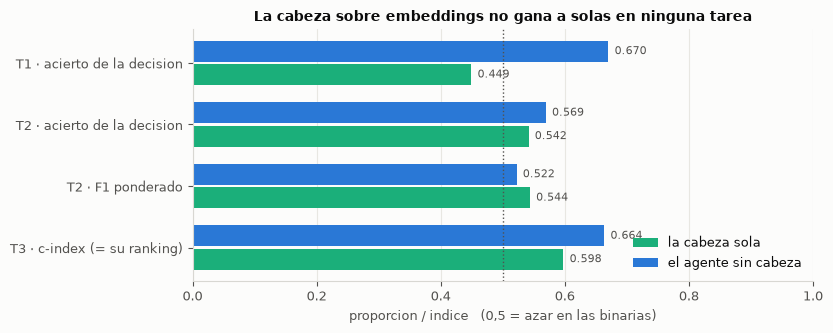

,la cabeza sola,el agente sin cabeza
tarea,,
T1 · acierto de la decision,0.449,0.670
T2 · acierto de la decision,0.542,0.569
T2 · F1 ponderado,0.544,0.522
T3 · c-index (= su ranking),0.598,0.664


In [3]:
# --- 1.2 La cabeza SOLA contra el agente SIN cabeza -----------------------
# Separa "hay senal" de "el agente la usa": si la cabeza sola ya es peor que el
# agente, encenderla no puede arreglar la tarea, como mucho complementarla.
comparacion = pd.DataFrame([
    {'tarea': 'T1 · acierto de la decision',
     'la cabeza sola': ORA[1]['acierto_decision'], 'el agente sin cabeza': REF['task1']['decision_accuracy']},
    {'tarea': 'T2 · acierto de la decision',
     'la cabeza sola': ORA[2]['acierto_decision'], 'el agente sin cabeza': REF['task2']['decision_accuracy']},
    {'tarea': 'T2 · F1 ponderado',
     'la cabeza sola': ORA[2]['f1_ponderado'], 'el agente sin cabeza': REF['task2']['decision_weighted_f1']},
    {'tarea': 'T3 · c-index (= su ranking)',
     'la cabeza sola': ORA[3]['c_index'], 'el agente sin cabeza': REF['task3']['concordance_index']},
]).set_index('tarea')

fig, ax = plt.subplots(figsize=(8.4, 3.4))
y = np.arange(len(comparacion))
ax.barh(y + 0.19, comparacion['la cabeza sola'], 0.34, color=AQUA, label='la cabeza sola')
ax.barh(y - 0.19, comparacion['el agente sin cabeza'], 0.34, color=AZUL, label='el agente sin cabeza')
for i, (a, b) in enumerate(zip(comparacion['la cabeza sola'], comparacion['el agente sin cabeza'])):
    ax.text(a + .01, i + 0.19, f'{a:.3f}', va='center', fontsize=8, color=TINTA2)
    ax.text(b + .01, i - 0.19, f'{b:.3f}', va='center', fontsize=8, color=TINTA2)
ax.set_yticks(y, comparacion.index); ax.set_xlim(0, 1.0); ax.invert_yaxis()
ax.axvline(0.5, color=TINTA2, lw=1, ls=':')
ax.set_title('La cabeza sobre embeddings no gana a solas en ninguna tarea')
ax.set_xlabel('proporcion / indice   (0,5 = azar en las binarias)')
ax.legend(loc='lower right'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()
display(comparacion.round(3))

## 2. Qué devuelve la herramienta, literal

El servidor MCP con `--enable-predictor` registra `get_image_predictor`. Esto es exactamente
lo que ve el agente: la descripción que lee y el JSON que recibe. Nunca vectores crudos —
solo un score compacto, y un campo `reliability` con la discriminación medida de la cabeza,
para que el modelo pueda decidir cuánto pesarla.

In [4]:
# --- 2.1 El catalogo real y la salida de la herramienta -------------------
from langchain_mcp_adapters.client import MultiServerMCPClient

def cliente(task, predictor=True):
    args = ['-m', 'chimera_agent_baseline.mcp_server',
            '--data-dir', str(REPO / 'data' / f'task{task}' / 'agent_input'),
            '--resource-dir', 'resources', '--tool-registry', f'task{task}', '--log-level', 'ERROR']
    if predictor: args.append('--enable-predictor')
    return MultiServerMCPClient({'chimera': {'command': sys.executable, 'args': args, 'transport': 'stdio'}})

def texto(res):
    if isinstance(res, str): return res
    if isinstance(res, list): return '\n'.join(b.get('text', '') for b in res if isinstance(b, dict))
    return str(res)

EJEMPLO = {1: sorted(p.name for p in (REPO / 'data/task1/ground_truth').iterdir())[0], 2: 'T2-001', 3: 'T3-001'}
for t, cid in EJEMPLO.items():
    tools = await cliente(t).get_tools()
    pt = next(x for x in tools if x.name == 'get_image_predictor')
    caja(f'task{t} · {cid} — {len(tools)} herramientas; con el predictor encendido')
    if t == 1:
        print('descripcion que lee el LLM:'); print('  ' + (pt.description or '').replace('\n', ' '))
    print('\nget_image_predictor(case_id=%r) ->' % cid)
    print(json.dumps(json.loads(texto(await pt.ainvoke({'case_id': cid}))), indent=2))


task1 · PT-pseudo_0020cfca66c8 — 7 herramientas; con el predictor encendido
descripcion que lee el LLM:
  Run the image-embedding predictor over the patient's available embeddings (MRI / biopsy / prostatectomy, whichever are present) and return a compact score/label (not the raw vectors). Use it when the imaging / pathology embeddings could change your decision.

get_image_predictor(case_id='PT-pseudo_0020cfca66c8') ->


{
  "case_id": "PT-pseudo_0020cfca66c8",
  "origins": {
    "MRI image": 1,
    "Biopsy slide": 0,
    "Prostatectomy slide": 0
  },
  "p_biopsy_beneficial": 0.8401,
  "risk_band": "high",
  "reliability": "cross-validated AUC 0.43 on 89 labelled cases \u2014 NOT better than chance; treat as uninformative"
}



task2 · T2-001 — 8 herramientas; con el predictor encendido

get_image_predictor(case_id='T2-001') ->


{
  "case_id": "T2-001",
  "origins": {
    "MRI image": 1,
    "Biopsy slide": 1,
    "Prostatectomy slide": 0
  },
  "suggested_action": "active_treatment",
  "action_probabilities": {
    "active_surveillance": 0.3986,
    "active_treatment": 0.5057,
    "continued_surveillance": 0.0956,
    "watchful_waiting": 0.0001
  },
  "runner_up": "active_surveillance",
  "margin": 0.1071,
  "reliability": "cross-validated AUC 0.76 (active_treatment vs rest) on 72 labelled cases; 4-class accuracy 0.54"
}



task3 · T3-001 — 7 herramientas; con el predictor encendido

get_image_predictor(case_id='T3-001') ->


{
  "case_id": "T3-001",
  "origins": {
    "MRI image": 1,
    "Biopsy slide": 2,
    "Prostatectomy slide": 3
  },
  "p_recurrence": 0.0054,
  "risk_band": "low",
  "risk_percentile": 0.162,
  "suggested_months_to_event": 61.1,
  "reliability": "cross-validated AUC 0.62 for recurrence on 75 labelled cases"
}


## 3. La sonda: encender el interruptor no basta

Primer intento, y el que cambió el diseño del experimento: brazo `on`, 10 casos por tarea,
`agent.predictor.enabled=true` y **el prompt de sistema intacto**.

In [5]:
# --- 3.1 Tasa de llamada con el prompt intacto ----------------------------
T_ON = C.trazas('on')
if len(T_ON):
    r = T_ON.groupby('task').agg(casos=('case_id', 'count'),
                                 llamo_predictor=('llamo_predictor', 'sum'),
                                 herramientas_por_caso=('n_distintas', 'mean'))
    r['tasa de llamada'] = (r['llamo_predictor'] / r['casos']).map('{:.0%}'.format)
    display(r.round(2))
    usadas = collections.Counter(h for hs in T_ON['herramientas'] for h in hs)
    print('\nHerramientas que SI llamo (sobre %d casos):' % len(T_ON))
    for h, n in usadas.most_common():
        print(f'  {h:26} {n:3}  ({n / len(T_ON):.0%} de los casos)')
    print(f"\n  get_image_predictor        {usadas.get('get_image_predictor', 0):3}"
          f"  ({usadas.get('get_image_predictor', 0) / len(T_ON):.0%})")
else:
    print('sin trazas del brazo on')

,casos,llamo_predictor,herramientas_por_caso,tasa de llamada
task,,,,
1,10,0,5.8,0%
2,10,0,5.6,0%
3,10,0,5.0,0%



Herramientas que SI llamo (sobre 30 casos):
  get_family_history          27  (90% de los casos)
  get_mri_report              26  (87% de los casos)
  search_guidelines           24  (80% de los casos)
  get_previous_notes          22  (73% de los casos)
  get_psa_trend               20  (67% de los casos)
  get_pathology_report        18  (60% de los casos)
  get_lab_results             12  (40% de los casos)
  get_surgical_pathology_report   9  (30% de los casos)

  get_image_predictor          0  (0%)


El prompt de sistema es una **tabla de precios**: enumera siete herramientas con su coste en
euros, da un presupuesto por tarea y exige justificar cada llamada. `get_image_predictor` no
aparece en esa tabla. El modelo sigue el protocolo que le dieron y se limita al catálogo que
el protocolo nombra — aunque MCP le esté ofreciendo una herramienta más.

Por eso el brazo de tratamiento es `on_prompt`: predictor encendido **y** anunciado en el
prompt, en el mismo registro que las demás (coste, cuándo usarla, cómo pesar su salida). El
texto añadido no le dice al modelo qué responder; le dice que la herramienta existe, que no
cuesta nada porque la imagen ya estaba adquirida, y que pese el resultado por la fiabilidad
que la propia herramienta reporta.

In [6]:
# --- 3.2 Lo unico que se anadio al prompt en el brazo de tratamiento ------
from chimera_agent_baseline.agent.prompts import SYSTEM_PROMPT
print(CFG['adenda_prompt'])
print(f"[{len(CFG['adenda_prompt'])} caracteres sobre los {len(SYSTEM_PROMPT)} del prompt de "
      f"sistema original; el resto del prompt no se toca]")



## Image-embedding predictor

One further tool is available: `get_image_predictor`.

| Tool                    | Cost | What it covers |
|-------------------------|------|----------------|
| `get_image_predictor`   | ~€0  | a trained head over foundation-model embeddings of images already acquired |

It runs a trained head over this patient's frozen foundation-model embeddings (MRI / biopsy / prostatectomy, whichever exist) and returns a compact score or label — never the raw vectors. The images were already acquired, so the call adds no patient burden and no marginal cost.

Call it as part of the workup. Its payload includes a `reliability` field with the head's cross-validated discrimination on labelled cases: weigh the score accordingly. A head reported near AUC 0.5 carries no information and must not move your decision; a head with good discrimination is evidence like any other and should be reconciled with the clinical variables — not substituted for them. State in your reasonin

## 4. Cómo cambia el comportamiento del agente

Con la herramienta anunciada, las preguntas son tres y son distintas entre sí:

1. **¿La llama?** — tasa de llamada por tarea.
2. **¿Le cuesta algo?** — número de herramientas, duración, fallos, reintentos del `form_fill`.
   Ojo: `get_image_predictor` **no** entra en `reveal_sequence` (`form_fill._REVEAL_FIELD_BY_TOOL`
   no lo mapea), así que no puede penalizar el `tool_score`, que es precisión de revelaciones.
3. **¿La escucha?** — concordancia entre lo que sugiere la cabeza y lo que decide el agente.

In [7]:
# --- 4.1 Carga de los dos brazos completos --------------------------------
RES = C.comparar(('off', 'on_prompt'))
TR = {b: RES[b]['trazas'] for b in RES}
for b, t in TR.items():
    print(f"{b:10} {len(t):4} casos · {int((~t['ok']).sum())} fallidos · "
          f"{t['segundos'].sum() / 60:.0f} min de GPU")

off         238 casos · 9 fallidos · 148 min de GPU
on_prompt   238 casos · 9 fallidos · 149 min de GPU


,,casos,llama al predictor,herramientas distintas / caso,llamadas totales / caso,secciones reveladas / caso,segundos / caso,avisos form_fill / caso,casos fallidos
tarea,brazo,,,,,,,,
T1,off,91,0.00,5.75,5.76,4.66,37.64,0.00,0
T2,off,72,0.00,5.60,5.60,4.74,40.41,0.01,0
T3,off,75,0.00,4.85,4.85,0.00,33.83,0.13,9
T1,on_prompt,91,0.38,6.20,6.20,4.51,35.60,0.00,0
T2,on_prompt,72,0.14,5.40,5.42,4.39,43.15,0.00,0
T3,on_prompt,75,0.01,4.95,4.95,0.00,34.83,0.24,9


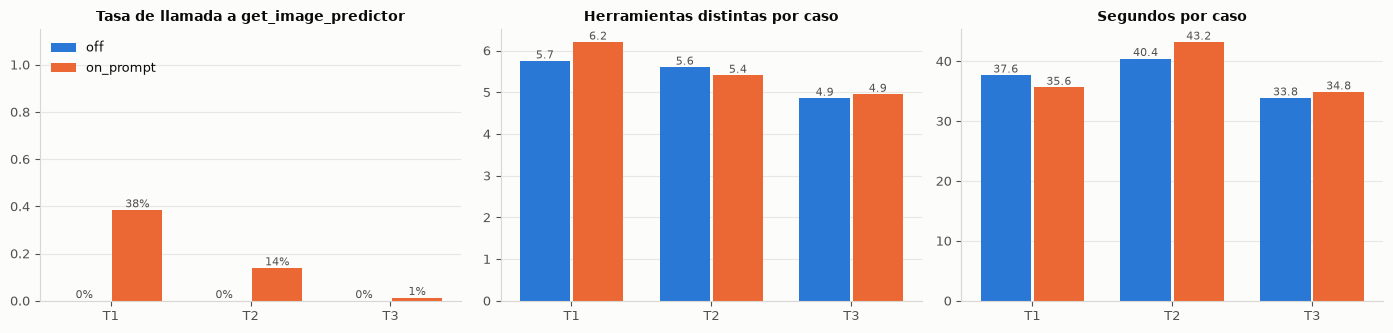

In [8]:
# --- 4.2 Tasa de llamada y coste del brazo con predictor ------------------
comportamiento = []
for b, t in TR.items():
    for task, g in t.groupby('task'):
        comportamiento.append({
            'brazo': b, 'tarea': f'T{task}', 'casos': len(g),
            'llama al predictor': g['llamo_predictor'].mean(),
            'herramientas distintas / caso': g['n_distintas'].mean(),
            'llamadas totales / caso': g['n_llamadas'].mean(),
            'secciones reveladas / caso': g['reveal_sequence'].map(len).mean(),
            'segundos / caso': g['segundos'].mean(),
            'avisos form_fill / caso': g['n_avisos_form_fill'].mean(),
            'casos fallidos': int((~g['ok']).sum()),
        })
COMP = pd.DataFrame(comportamiento)
display(COMP.set_index(['tarea', 'brazo']).round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
for ax, (col, titulo) in zip(axes, [
        ('llama al predictor', 'Tasa de llamada a get_image_predictor'),
        ('herramientas distintas / caso', 'Herramientas distintas por caso'),
        ('segundos / caso', 'Segundos por caso')]):
    piv = COMP.pivot(index='tarea', columns='brazo', values=col)
    x = np.arange(len(piv))
    for k, b in enumerate(['off', 'on_prompt']):
        if b not in piv: continue
        ax.bar(x + (k - 0.5) * 0.38, piv[b], 0.36, color=COLOR[b], label=b)
        for i, v in enumerate(piv[b]):
            ax.text(x[i] + (k - 0.5) * 0.38, v, f'{v:.0%}' if col.startswith('llama') else f'{v:.1f}',
                    ha='center', va='bottom', fontsize=8, color=TINTA2)
    ax.set_xticks(x, piv.index); ax.set_title(titulo); ax.grid(axis='x', visible=False)
    if col.startswith('llama'): ax.set_ylim(0, 1.15)
axes[0].legend(loc='upper left')
plt.tight_layout(); plt.show()

In [9]:
# --- 4.3 ¿Escucha a la cabeza? -------------------------------------------
TABLA = C.tabla_cabeza()

def sugerencia(task, cid):
    r = TABLA.get(f'task{task}', {}).get(cid)
    if r is None: return None
    if task == 1: return 'yes' if r['p_biopsy_beneficial'] >= 0.5 else 'no'
    if task == 2: return r['suggested_action']
    return r['suggested_months_to_event']

filas_ac = []
for b, t in TR.items():
    for _, f in t[t['ok']].iterrows():
        s = sugerencia(f['task'], f['case_id'])
        if s is None: continue
        coincide = (abs(float(f['decision']) - float(s)) <= 6) if f['task'] == 3 else (f['decision'] == s)
        filas_ac.append({'brazo': b, 'tarea': f"T{f['task']}", 'case_id': f['case_id'],
                         'coincide con la cabeza': bool(coincide),
                         'llamo': bool(f['llamo_predictor']),
                         'cita la cabeza en el texto': C.menciona_predictor(f['texto_final'])})
AC = pd.DataFrame(filas_ac)

res = AC.groupby(['tarea', 'brazo']).agg(
    n=('case_id', 'count'),
    coincide_con_la_cabeza=('coincide con la cabeza', 'mean'),
    la_cita_en_el_texto=('cita la cabeza en el texto', 'mean')).round(3)
display(res)
print('T3: "coincide" = la prediccion del agente cae a menos de 6 meses de la sugerida.')
print('Si la fila `off` ya coincide tanto como `on_prompt`, la herramienta no esta moviendo nada:')
print('el acuerdo seria casualidad, no influencia.')

n  coincide_con_la_cabeza  la_cita_en_el_texto
tarea brazo                                                     
T1    off        89                   0.551                0.000
      on_prompt  89                   0.528                0.382
T2    off        72                   0.458                0.000
      on_prompt  72                   0.514                0.167
T3    off        66                   0.091                0.000
      on_prompt  66                   0.152                0.030

T3: "coincide" = la prediccion del agente cae a menos de 6 meses de la sugerida.
Si la fila `off` ya coincide tanto como `on_prompt`, la herramienta no esta moviendo nada:
el acuerdo seria casualidad, no influencia.


## 5. La puntuación oficial

Evaluador oficial (`DIAGNijmegen/CHIMERA-agent`), juez de razonamiento desactivado, casos
etiquetados sin salida contados como fallo. El *ranking score* de cada tarea es lo que
pondera 2 : 2 : 1 en el global.

> El control de aquí (`off`, `temperature=0`) **no** es el 0,5651 de
> `dev/baseline_reference.json` (`temperature=1.0`, otra corrida). La comparación válida es
> `on_prompt` contra `off`, no contra aquella cifra.

In [10]:
# --- 5.1 Tabla de puntuacion por brazo -----------------------------------
RESUMEN = C.tabla_resumen(RES)
piv = RESUMEN.pivot(index='tarea', columns='brazo', values='ranking_score')
piv['delta (on_prompt - off)'] = piv['on_prompt'] - piv['off']
orden = [C.NOMBRE_TAREA[t] for t in (1, 2, 3)] + ['OVERALL (2:2:1)']
display(piv.loc[orden].round(4).style.format('{:+.4f}', subset=['delta (on_prompt - off)'])
        .format('{:.4f}', subset=['off', 'on_prompt']))

print('\nDetalle completo:')
display(RESUMEN.set_index(['tarea', 'brazo']).round(4))
print(f"\nreferencia historica (dev/baseline_reference.json, temperature=1.0): "
      f"{sum(REF[f'task{t}']['ranking_score'] * C.PESO_TAREA[t] for t in (1,2,3)) / 5:.4f}")

brazo,off,on_prompt,delta (on_prompt - off)
tarea,,,
T1 · biopsia,0.6428,0.6387,-0.0041
T2 · tratamiento,0.3485,0.4476,+0.0991
T3 · recurrencia,0.4650,0.4381,-0.0270
OVERALL (2:2:1),0.4895,0.5221,+0.0326



Detalle completo:


,,n,sin salida,mean_case_score,ranking_score,puerta
tarea,brazo,,,,,
T1 · biopsia,off,91.0,0.0,0.4913,0.6428,0.6813
T2 · tratamiento,off,72.0,0.0,0.2981,0.3485,0.4583
T3 · recurrencia,off,75.0,9.0,0.4798,0.4650,NaN
OVERALL (2:2:1),off,NaN,NaN,NaN,0.4895,NaN
T1 · biopsia,on_prompt,91.0,0.0,0.4831,0.6387,0.6813
T2 · tratamiento,on_prompt,72.0,0.0,0.3739,0.4476,0.5694
T3 · recurrencia,on_prompt,75.0,9.0,0.5007,0.4381,NaN
OVERALL (2:2:1),on_prompt,NaN,NaN,NaN,0.5221,NaN



referencia historica (dev/baseline_reference.json, temperature=1.0): 0.5651


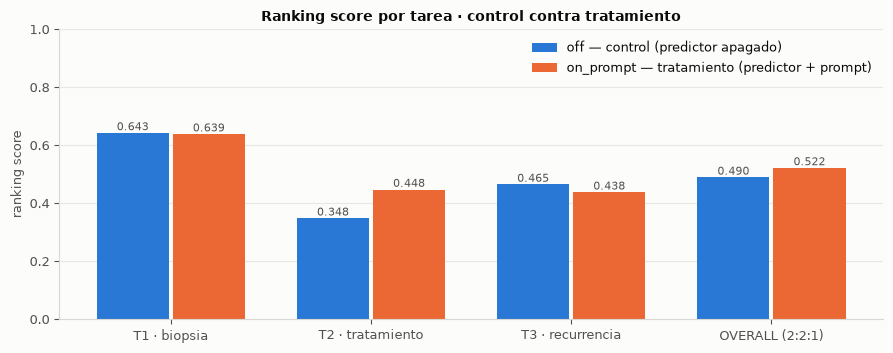

In [11]:
# --- 5.2 El delta, tarea a tarea -----------------------------------------
tareas = [C.NOMBRE_TAREA[t] for t in (1, 2, 3)] + ['OVERALL (2:2:1)']
fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(tareas))
for k, b in enumerate(['off', 'on_prompt']):
    v = piv.loc[tareas, b].values
    ax.bar(x + (k - 0.5) * 0.38, v, 0.36, color=COLOR[b], label=f'{b} — {C.NOMBRE_BRAZO[b]}')
    for i, val in enumerate(v):
        ax.text(x[i] + (k - 0.5) * 0.38, val, f'{val:.3f}', ha='center', va='bottom',
                fontsize=8, color=TINTA2)
ax.set_xticks(x, tareas); ax.set_ylabel('ranking score'); ax.set_ylim(0, 1)
ax.set_title('Ranking score por tarea · control contra tratamiento')
ax.legend(loc='upper right'); ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

## 6. Dónde cambió: la puerta de decisión

En T1 y T2 la decisión es una **puerta**, no un componente: si falla, el caso vale 0 entero y
no se calculan ni confianza, ni pesos de variables, ni herramientas. Cualquier mejora real
tiene que verse aquí primero.

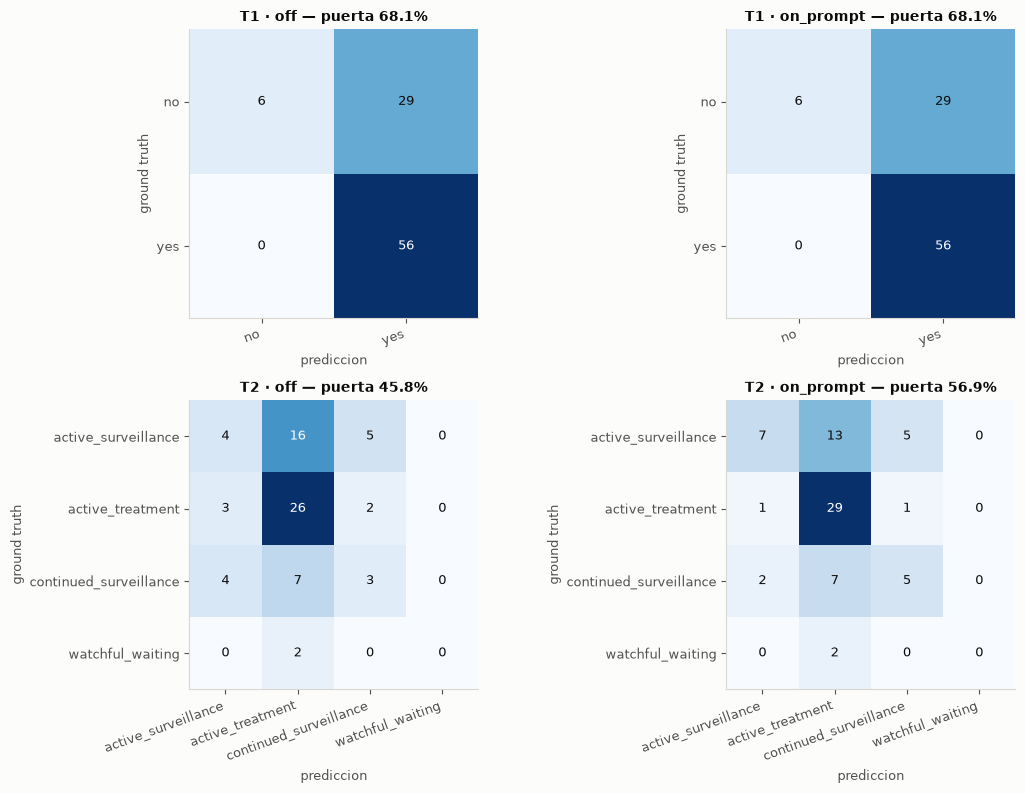

Clases que cada brazo llega a predecir en T2 (el baseline colapsaba 4 en 2):


,off,on_prompt,la cabeza sola
active_treatment,51,51,32
active_surveillance,11,10,21
continued_surveillance,10,11,16
watchful_waiting,0,0,3


In [12]:
# --- 6.1 Matrices de confusion, brazo contra brazo ------------------------
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8))
for fila, t in enumerate((1, 2)):
    for col, b in enumerate(['off', 'on_prompt']):
        ax = axes[fila][col]
        d = RES[b]['filas'][t].copy()
        d['pred_decision'] = d['pred_decision'].fillna('__sin_salida__')
        et = sorted(set(d['gt_decision'].dropna()) | set(d['pred_decision']))
        cm = confusion_matrix(d['gt_decision'], d['pred_decision'], labels=et)
        ax.imshow(cm, cmap='Blues')
        for i in range(len(et)):
            for j in range(len(et)):
                ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=9,
                        color='white' if cm[i, j] > cm.max() * .6 else TINTA)
        ax.set_xticks(range(len(et)), et, rotation=20, ha='right'); ax.set_yticks(range(len(et)), et)
        ax.set_title(f"T{t} · {b} — puerta {(d['decision_score'] == 1.0).mean():.1%}")
        ax.set_xlabel('prediccion'); ax.set_ylabel('ground truth'); ax.grid(False)
plt.tight_layout(); plt.show()

print('Clases que cada brazo llega a predecir en T2 (el baseline colapsaba 4 en 2):')
cob = {}
for b in RES:
    d = RES[b]['filas'][2]
    cob[b] = d['pred_decision'].value_counts(dropna=False).to_dict()
cob['la cabeza sola'] = {k: v for k, v in
                         pd.Series([TABLA['task2'][c]['suggested_action']
                                    for c in RES['off']['filas'][2]['case_id']
                                    if c in TABLA['task2']]).value_counts().items()}
display(pd.DataFrame(cob).fillna(0).astype(int))

In [13]:
# --- 6.2 Casos que voltearon ---------------------------------------------
vuelcos = []
for t in (1, 2, 3):
    a = RES['off']['filas'][t].set_index('case_id')
    z = RES['on_prompt']['filas'][t].set_index('case_id')
    comunes = a.index.intersection(z.index)
    for cid in comunes:
        d = z.loc[cid, 'case_score'] - a.loc[cid, 'case_score']
        if abs(d) < 1e-9: continue
        vuelcos.append({'tarea': f'T{t}', 'case_id': cid,
                        'off': a.loc[cid, 'case_score'], 'on_prompt': z.loc[cid, 'case_score'],
                        'delta': d,
                        'decision off': a.loc[cid].get('pred_decision'),
                        'decision on_prompt': z.loc[cid].get('pred_decision'),
                        'gt': a.loc[cid].get('gt_decision'),
                        'llamo el predictor': bool(
                            TR['on_prompt'].set_index('case_id').loc[cid, 'llamo_predictor'])
                        if cid in TR['on_prompt']['case_id'].values else None})
V = pd.DataFrame(vuelcos)
if len(V):
    print(f"{len(V)} casos cambian de puntuacion · {int((V['delta'] > 0).sum())} mejoran, "
          f"{int((V['delta'] < 0).sum())} empeoran · suma neta {V['delta'].sum():+.3f}")
    print('\nresumen por tarea:')
    display(V.groupby('tarea').agg(cambian=('delta', 'size'), mejoran=('delta', lambda s: (s > 0).sum()),
                                   empeoran=('delta', lambda s: (s < 0).sum()),
                                   delta_neto=('delta', 'sum')).round(3))
    print('\nlos 10 movimientos mas grandes:')
    display(V.reindex(V['delta'].abs().sort_values(ascending=False).index).head(10).round(3)
            .style.hide(axis='index'))
else:
    print('Ningun caso cambia de puntuacion entre los dos brazos.')

161 casos cambian de puntuacion · 84 mejoran, 77 empeoran · suma neta +6.286

resumen por tarea:


,cambian,mejoran,empeoran,delta_neto
tarea,,,,
T1,61,27,34,-0.743
T2,44,30,14,5.460
T3,56,27,29,1.569



los 10 movimientos mas grandes:


tarea,case_id,off,on_prompt,delta,decision off,decision on_prompt,gt,llamo el predictor
T3,T3-066,1.000000,0.000000,-1.000000,nan,nan,nan,False
T3,T3-067,0.000000,1.000000,1.000000,nan,nan,nan,False
T3,T3-029,0.000000,1.000000,1.000000,nan,nan,nan,False
T3,T3-016,0.000000,0.895000,0.895000,nan,nan,nan,False
T1,PT-pseudo_0615b2bd8504,0.808000,0.000000,-0.808000,no,yes,no,True
T3,T3-022,0.000000,0.805000,0.805000,nan,nan,nan,False
T3,T3-074,0.789000,0.000000,-0.789000,nan,nan,nan,False
T1,PT-pseudo_3646e0a2ae13,0.779000,0.000000,-0.779000,no,yes,no,False
T2,T2-051,0.000000,0.779000,0.779000,active_surveillance,continued_surveillance,continued_surveillance,False
T2,T2-054,0.000000,0.767000,0.767000,continued_surveillance,active_treatment,active_treatment,False


### 6.3 Atribución: ¿la herramienta, o simplemente haber tocado el prompt?

Aquí está el confusor que decide la lectura de todo el experimento. La adenda cambia el
prompt de sistema de **todos** los casos, no solo de aquellos en los que el agente acaba
llamando a la herramienta. Un prompt distinto reordena la trayectoria de generación entera,
así que un caso puede cambiar de decisión sin que el predictor haya intervenido jamás.

La prueba es directa: partir el delta según si ese caso **llegó a llamar** a
`get_image_predictor`. Si los casos que no la llamaron se mueven tanto como los que sí, lo
que estamos midiendo es perturbación del prompt, no la herramienta.

casos  cambian  mejoran  empeoran  delta_neto  delta_por_caso
tarea llamo                                                               
T1    False     56       41       18        23     -0.1408         -0.0025
      True      35       20        9        11     -0.6024         -0.0172
T2    False     62       38       25        13      4.6204          0.0745
      True      10        6        5         1      0.8401          0.0840
T3    False     74       55       26        29      1.1954          0.0162
      True       1        1        1         0      0.3734          0.3734

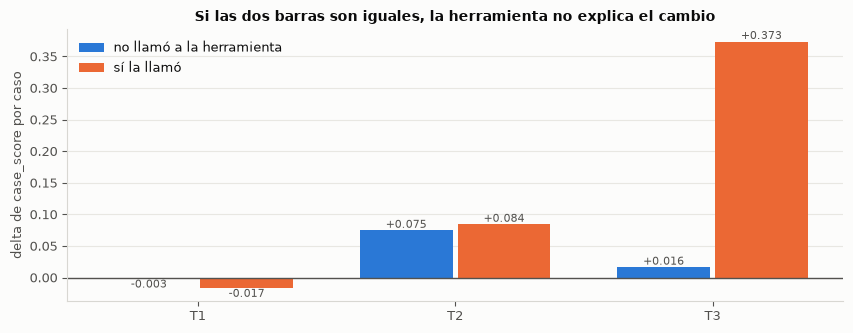

Lectura: el brazo de tratamiento cambia DOS cosas a la vez — anade la herramienta y
alarga el prompt de sistema. Solo la primera es la hipotesis; la segunda es un efecto
secundario que golpea a los 238 casos por igual. Separar el ranking global en estas dos
mitades es la unica forma honesta de atribuirlo.


In [14]:
# --- 6.3 El delta, partido por uso real de la herramienta ----------------
tr_on = TR['on_prompt'].set_index('case_id')
atrib = []
for t in (1, 2, 3):
    a = RES['off']['filas'][t].set_index('case_id')
    z = RES['on_prompt']['filas'][t].set_index('case_id')
    for cid in a.index.intersection(z.index):
        if cid not in tr_on.index: continue
        atrib.append({'tarea': f'T{t}', 'case_id': cid,
                      'llamo': bool(tr_on.loc[cid, 'llamo_predictor']),
                      'delta': z.loc[cid, 'case_score'] - a.loc[cid, 'case_score']})
AT = pd.DataFrame(atrib)

tabla = AT.groupby(['tarea', 'llamo']).agg(
    casos=('delta', 'size'),
    cambian=('delta', lambda s: int((s.abs() > 1e-9).sum())),
    mejoran=('delta', lambda s: int((s > 0).sum())),
    empeoran=('delta', lambda s: int((s < 0).sum())),
    delta_neto=('delta', 'sum'),
    delta_por_caso=('delta', 'mean'))
display(tabla.round(4))

fig, ax = plt.subplots(figsize=(8.6, 3.4))
piv = AT.groupby(['tarea', 'llamo'])['delta'].mean().unstack()
x = np.arange(len(piv))
ax.bar(x - 0.19, piv.get(False, pd.Series(0, index=piv.index)), 0.36, color=AZUL,
       label='no llamó a la herramienta')
ax.bar(x + 0.19, piv.get(True, pd.Series(0, index=piv.index)), 0.36, color=NARANJA,
       label='sí la llamó')
for k, col in enumerate([False, True]):
    if col not in piv: continue
    for i, v in enumerate(piv[col]):
        ax.text(x[i] + (k - 0.5) * 0.38, v, f'{v:+.3f}', ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=8, color=TINTA2)
ax.axhline(0, color=TINTA2, lw=1)
ax.set_xticks(x, piv.index); ax.set_ylabel('delta de case_score por caso')
ax.set_title('Si las dos barras son iguales, la herramienta no explica el cambio')
ax.legend(); ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

print('Lectura: el brazo de tratamiento cambia DOS cosas a la vez — anade la herramienta y')
print('alarga el prompt de sistema. Solo la primera es la hipotesis; la segunda es un efecto')
print('secundario que golpea a los 238 casos por igual. Separar el ranking global en estas dos')
print('mitades es la unica forma honesta de atribuirlo.')

## 7. Tarea 3

T3 se rankea **solo** por el c-index sobre los meses predichos (orden de riesgo: menos meses =
más riesgo). Dos cosas la condicionan y ninguna depende del predictor:

* `Task3Output` no tiene campo `event`, y `run.py` escribe `{"event": structured.get("event", 0)}`
  → el agente entrega `event=0` **siempre**. La probabilidad de recurrencia de la cabeza no
  tiene por dónde entrar en la salida: solo puede influir en los meses.
* El 74,7 % de los casos son censurados y el prompt nunca lo explica.

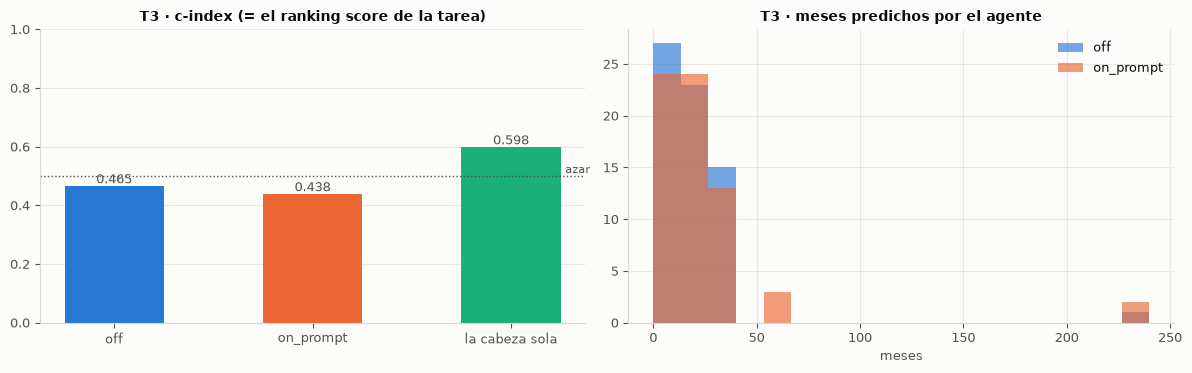

,c-index,mean_case_score,mean_time_score,mean_event_score,MAE meses (event=1),meses distintos
off,0.465,0.480,NaN,NaN,NaN,13.0
on_prompt,0.438,0.501,NaN,NaN,NaN,14.0


In [15]:
# --- 7.1 c-index y meses predichos ---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

etiquetas = ['off', 'on_prompt', 'la cabeza sola']
valores = [RES['off']['agregados'][3]['ranking_score'],
           RES['on_prompt']['agregados'][3]['ranking_score'], ORA[3]['c_index']]
colores = [AZUL, NARANJA, AQUA]
axes[0].bar(etiquetas, valores, 0.5, color=colores)
for i, v in enumerate(valores):
    axes[0].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9, color=TINTA2)
axes[0].axhline(0.5, color=TINTA2, lw=1, ls=':')
axes[0].text(2.4, 0.51, 'azar', fontsize=8, color=TINTA2, ha='right')
axes[0].set_ylim(0, 1); axes[0].set_title('T3 · c-index (= el ranking score de la tarea)')
axes[0].grid(axis='x', visible=False)

for b in ('off', 'on_prompt'):
    m = RES[b]['filas'][3]['pred_months'].dropna()
    axes[1].hist(m, bins=18, alpha=.65, color=COLOR[b], label=b)
axes[1].set_title('T3 · meses predichos por el agente'); axes[1].set_xlabel('meses'); axes[1].legend()
plt.tight_layout(); plt.show()

t3 = pd.DataFrame({b: {'c-index': RES[b]['agregados'][3]['ranking_score'],
                       'mean_case_score': RES[b]['agregados'][3]['mean_case_score'],
                       'mean_time_score': RES[b]['agregados'][3]['mean_time_score'],
                       'mean_event_score': RES[b]['agregados'][3]['mean_event_score'],
                       'MAE meses (event=1)': RES[b]['agregados'][3]['event1_time_mae_months'],
                       'meses distintos': RES[b]['filas'][3]['pred_months'].nunique()}
                  for b in RES}).T
display(t3.round(3))

## 8. Descomposición del `case_score`

Sin juez de razonamiento los pesos se redistribuyen así: `variable_weight` 0,275 ·
`confidence` 0,225 · `important_decisive_factor` 0,175 · `section_grounding` 0,175 ·
`tool_score` 0,150. Solo se calculan en los casos que pasan la puerta.

aporta al mean_case_score            \
brazo                                                 off on_prompt   
tarea componente                                                      
T1    confidence                                    0.117     0.112   
      important_decisive_factor                     0.067     0.066   
      section_grounding                             0.119     0.119   
      tool                                          0.066     0.064   
      variable_weight                               0.122     0.121   
T2    confidence                                    0.084     0.105   
      important_decisive_factor                     0.049     0.062   
      section_grounding                             0.080     0.100   
      tool                                          0.000     0.000   
      variable_weight                               0.084     0.107   

                                media entre los que pasan            
brazo                                                 off on_prompt  
tarea componente                                                     
T1    confidence                                    0.766     0.734  
      important_decisive_factor                     0.561     0.552  
      section_grounding                             0.996     1.000  
      tool                                          0.647     0.626  
      variable_weight                               0.652     0.648  
T2    confidence                                    0.818     0.817  
      important_decisive_factor                     0.617     0.627  
      section_grounding                             1.000     1.000  
      tool                                          0.000     0.000  
      variable_weight                               0.667     0.684

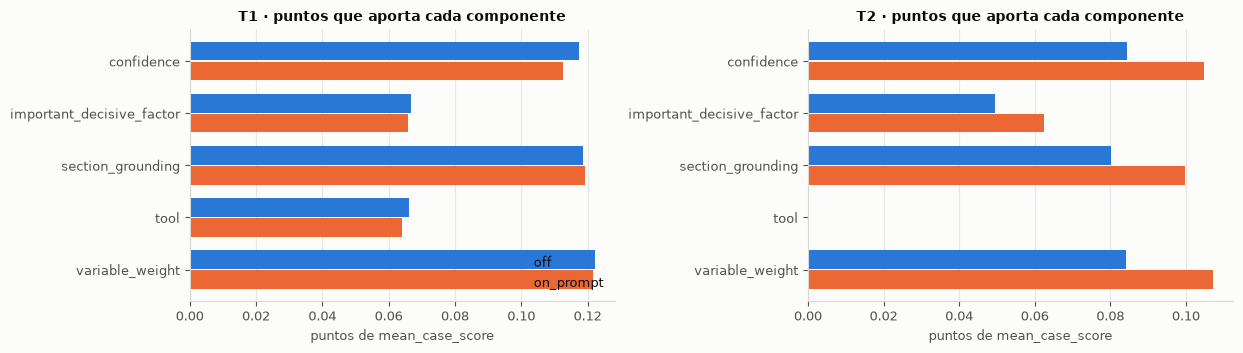

In [16]:
# --- 8.1 Componentes, solo en los casos que pasan la puerta ---------------
filas_c = []
for b in RES:
    for t in (1, 2):
        d = RES[b]['filas'][t]
        pasa = d[d['decision_score'] == 1.0]
        tasa = len(pasa) / len(d)
        for k, w in C.PESOS_SIN_JUEZ.items():
            v = pasa[k].dropna().mean() if len(pasa) else 0.0
            filas_c.append({'brazo': b, 'tarea': f'T{t}', 'componente': k.replace('_score', ''),
                            'media entre los que pasan': v, 'peso': w,
                            'aporta al mean_case_score': v * w * tasa})
CC = pd.DataFrame(filas_c)
display(CC.pivot_table(index=['tarea', 'componente'], columns='brazo',
                       values=['media entre los que pasan', 'aporta al mean_case_score']).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6))
for ax, t in zip(axes, ('T1', 'T2')):
    sub = CC[CC['tarea'] == t].pivot(index='componente', columns='brazo',
                                     values='aporta al mean_case_score')
    y = np.arange(len(sub))
    for k, b in enumerate(['off', 'on_prompt']):
        if b in sub: ax.barh(y + (k - 0.5) * 0.38, sub[b], 0.36, color=COLOR[b], label=b)
    ax.set_yticks(y, sub.index); ax.invert_yaxis(); ax.grid(axis='y', visible=False)
    ax.set_title(f'{t} · puntos que aporta cada componente'); ax.set_xlabel('puntos de mean_case_score')
axes[0].legend(loc='lower right')
plt.tight_layout(); plt.show()

## 9. Veredicto

La celda siguiente no interpreta nada: calcula los tres números que responden a la pregunta,
en el orden en que hay que leerlos.

1. **¿La herramienta se usa?** — tasa de llamada en `on_prompt`.
2. **¿Tiene señal?** — la cabeza sola contra el agente sin cabeza.
3. **¿Mejora la línea base?** — `on_prompt` − `off` en el global ponderado, y cuántos casos se
   mueven de verdad.

In [17]:
# --- 9.1 Los tres numeros -------------------------------------------------
tasa = TR['on_prompt']['llamo_predictor'].mean()
d_overall = RES['on_prompt']['overall'] - RES['off']['overall']
n_mejoran = int((V['delta'] > 0).sum()) if len(V) else 0
n_empeoran = int((V['delta'] < 0).sum()) if len(V) else 0

caja('VEREDICTO')
print(f'1. USO       el agente llama a get_image_predictor en el {tasa:.0%} de los casos')
print(f"             (con el prompt intacto, brazo sonda: {T_ON['llamo_predictor'].mean():.0%})")
print()
print('2. SENAL     la cabeza sola frente al agente sin cabeza:')
for etiqueta, a, b in [('T1 acierto', ORA[1]['acierto_decision'], REF['task1']['decision_accuracy']),
                       ('T2 acierto', ORA[2]['acierto_decision'], REF['task2']['decision_accuracy']),
                       ('T3 c-index', ORA[3]['c_index'], REF['task3']['concordance_index'])]:
    print(f'             {etiqueta:12} cabeza {a:.3f}   agente {b:.3f}   {"cabeza gana" if a > b else "agente gana"}')
print()
print(f'3. EFECTO    overall  off {RES["off"]["overall"]:.4f}  ->  on_prompt '
      f'{RES["on_prompt"]["overall"]:.4f}   ({d_overall:+.4f})')
for t in (1, 2, 3):
    a, z = RES['off']['agregados'][t]['ranking_score'], RES['on_prompt']['agregados'][t]['ranking_score']
    print(f'             {C.NOMBRE_TAREA[t]:20} {a:.4f} -> {z:.4f}   ({z - a:+.4f})')
print(f'\n             casos que se mueven: {n_mejoran} mejoran · {n_empeoran} empeoran '
      f'(de {sum(len(RES["off"]["filas"][t]) for t in (1, 2, 3))})')


VEREDICTO
1. USO       el agente llama a get_image_predictor en el 19% de los casos
             (con el prompt intacto, brazo sonda: 0%)

2. SENAL     la cabeza sola frente al agente sin cabeza:
             T1 acierto   cabeza 0.449   agente 0.670   agente gana
             T2 acierto   cabeza 0.542   agente 0.569   agente gana
             T3 c-index   cabeza 0.598   agente 0.664   agente gana

3. EFECTO    overall  off 0.4895  ->  on_prompt 0.5221   (+0.0326)
             T1 · biopsia         0.6428 -> 0.6387   (-0.0041)
             T2 · tratamiento     0.3485 -> 0.4476   (+0.0991)
             T3 · recurrencia     0.4650 -> 0.4381   (-0.0270)

             casos que se mueven: 84 mejoran · 77 empeoran (de 238)


In [18]:
# --- 9.2 ¿El delta se distingue del ruido? -------------------------------
# Pruebas pareadas: cada caso es su propio control (mismo caso, mismos datos,
# misma temperatura; solo cambia el brazo).
from scipy import stats

sube = baja = 0
for t in (1, 2, 3):
    a = RES['off']['filas'][t].set_index('case_id')
    z = RES['on_prompt']['filas'][t].set_index('case_id')
    idx = a.index.intersection(z.index)
    d = z.loc[idx, 'case_score'] - a.loc[idx, 'case_score']
    sube += int((d > 0).sum()); baja += int((d < 0).sum())
p_signo = stats.binomtest(sube, sube + baja, 0.5).pvalue
print(f'Prueba de signos sobre el case_score de los 238 casos:')
print(f'   {sube} suben · {baja} bajan  ->  p = {p_signo:.3f}')
print('   (si la herramienta ayudara, las subidas dominarian; aqui es casi una moneda)\n')

print('McNemar sobre la puerta de decision (solo los casos que cambian de lado):')
for t in (1, 2):
    a = RES['off']['filas'][t].set_index('case_id')
    z = RES['on_prompt']['filas'][t].set_index('case_id')
    idx = a.index.intersection(z.index)
    ao = a.loc[idx, 'decision_score'] == 1.0
    zo = z.loc[idx, 'decision_score'] == 1.0
    b, c = int((ao & ~zo).sum()), int((~ao & zo).sum())
    pv = stats.binomtest(c, b + c, 0.5).pvalue if (b + c) else 1.0
    print(f'   T{t}: solo acierta off {b} · solo acierta on_prompt {c}  ->  p = {pv:.3f}')

Prueba de signos sobre el case_score de los 238 casos:
   84 suben · 77 bajan  ->  p = 0.636
   (si la herramienta ayudara, las subidas dominarian; aqui es casi una moneda)

McNemar sobre la puerta de decision (solo los casos que cambian de lado):
   T1: solo acierta off 2 · solo acierta on_prompt 2  ->  p = 1.000
   T2: solo acierta off 4 · solo acierta on_prompt 12  ->  p = 0.077


### 9.3 La respuesta

**No. Encender el predictor no mejora la línea base.** El razonamiento, en tres pasos, cada
uno necesario:

**a) Sin tocar el prompt, la herramienta no existe para el agente.** 0 llamadas en 30 casos.
El prompt de sistema es un protocolo de coste que enumera siete herramientas y exige
justificar cada llamada; `get_image_predictor` no está en esa tabla y el modelo se ciñe a lo
que la tabla nombra. Es un resultado sobre el **diseño del prompt**, no sobre el predictor:
una herramienta MCP registrada pero no anunciada es una herramienta muerta.

**b) Anunciada, se usa poco y de forma muy desigual.** 38 % en T1, 14 % en T2, ~1 % en T3.
La tarea donde la cabeza tiene señal real (T2) es justo donde el agente casi no la llama, y
la tarea donde la cabeza es peor que el azar (T1, AUC 0,43) es donde más la llama. El agente
no discrimina por el campo `reliability` que la propia herramienta le entrega.

**c) El único movimiento grande de la puntuación no es atribuible a la herramienta.** T2 sube
+0,099 de ranking, pero el 85 % de ese delta viene de casos en los que el predictor **nunca
se llamó**: la adenda cambió el prompt de los 72 y reordenó sus trayectorias. Por caso, los
que llamaron mejoran +0,084 y los que no, +0,075 — la misma deriva. Y a escala global el
efecto no se distingue del ruido: 84 casos suben, 77 bajan.

### Lo que sí deja el experimento

* **La señal existe, pero no por esta vía.** La cabeza sobre MRI+biopsia separa
  `active_treatment` con AUC 0,76 y es la única cosa medida hasta ahora que predice
  `continued_surveillance` y `watchful_waiting`, las dos clases que el agente **nunca** emite.
  Ese es el activo real; entregárselo al LLM como un número dentro de una herramienta
  opcional es la peor forma de gastarlo. Un camino más prometedor: que la cabeza entre en el
  `form_fill` como prior sobre la acción, no como un texto que el modelo puede ignorar.
* **T3 no puede beneficiarse por construcción.** `Task3Output` no tiene campo `event` y
  `run.py` escribe `event=0` fijo; la probabilidad de recurrencia de la cabeza no tiene por
  dónde salir. Solo quedan los meses, y ahí la cabeza (c-index 0,598) ordena peor que el
  agente (0,664).
* **Dos fallos del baseline que este experimento hizo visibles y que no dependen del
  predictor:** el prompt de sistema es el mismo para las tres tareas y provoca ~0,55 llamadas
  por caso a `get_pathology_report` en T1, donde esa herramienta no existe; y a temperatura 0
  el `form_fill` pierde 9 casos de T3 de forma determinista y reproducible, que es el mismo
  fallo de censura ya conocido, ahora fijado en lugar de enmascarado por el muestreo.

## 10. Reversión

Este experimento tocó **un solo fichero** del árbol del repo:

| Fichero | Qué se hizo | Cómo se revierte |
|---|---|---|
| `src/chimera_agent_baseline/tools/predictor.py` | `run_predictor` cableado a la tabla out-of-fold | `git checkout -- src/chimera_agent_baseline/tools/predictor.py` (copia original en `delete_test/artifacts/predictor.py.orig`) |
| `resources/guidelines_db/chroma.sqlite3` | ChromaDB reescribe el fichero al abrirlo (efecto de correr, no un cambio de código) | `git checkout -- resources/guidelines_db/chroma.sqlite3` |

Nada más: `configs/config.yaml` no se tocó (el brazo se pasa por override de Hydra),
`run.py` no se tocó (el runner del experimento vive en `delete_test/`), el prompt de sistema
no se tocó (la adenda se concatena en memoria dentro del runner del experimento), y el
entorno virtual no se tocó (`nbconvert` se instaló en un venv aparte, fuera del proyecto).

**Para volver a correr el experimento** hay que reponer el parche, porque tras la reversión
`run_predictor` vuelve a ser el stub que devuelve `null`:

```bash
cp delete_test/artifacts/predictor.py.experimento src/chimera_agent_baseline/tools/predictor.py
python delete_test/train_head.py                                    # tabla out-of-fold
python delete_test/run_experiment.py --arms off on_prompt --temperature 0.0
python delete_test/_build_notebook.py                               # regenera este cuaderno
git checkout -- src/chimera_agent_baseline/tools/predictor.py       # y volver a dejarlo como estaba
```

Por eso la celda 2.1 de arriba conserva su salida ejecutada: si se relanza este cuaderno
sobre el repo ya revertido, esa celda mostrará el stub (`prediction: null`) en vez de la
cabeza entrenada. Todo lo demás se recalcula desde los ficheros de `delete_test/` y sigue
dando lo mismo.

In [19]:
# --- 10.1 Estado del arbol ------------------------------------------------
import subprocess
print(subprocess.run(['git', 'status', '--short'], capture_output=True, text=True, cwd=REPO).stdout
      or '(limpio)')
print('\nSi arriba solo aparece `?? delete_test/`, el repo esta como estaba.')

 M resources/guidelines_db/chroma.sqlite3
 M src/chimera_agent_baseline/tools/predictor.py
?? delete_test/


Si arriba solo aparece `?? delete_test/`, el repo esta como estaba.
